<a href="https://colab.research.google.com/github/tarunsac/Gen-AI/blob/main/Applied_ML_EDA_NYC_Taxi_Trip_Duration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA NYC Taxi Trip Duration

Here, we are providing you the NYC-trip duration dataset. The aim of this assignment is just to explore the dataset and generate insights from it.

Here is the description of all the variables / features available in the dataset which will help you to perform EDA:

* id - a unique identifier for each trip
* vendor_id - a code indicating the provider associated with the trip record
* pickup_datetime - date and time when the meter was engaged
* dropoff_datetime - date and time when the meter was disengaged
* passenger_count - the number of passengers in the vehicle (driver entered value)
* pickup_longitude - the longitude where the meter was engaged
* pickup_latitude - the latitude where the meter was engaged
* dropoff_longitude - the longitude where the meter was disengaged
* dropoff_latitude - the latitude where the meter was disengaged
* store_and_fwd_flag - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y=store and forward; N=not a store and forward trip)
* trip_duration - (target) duration of the trip in seconds

# Task
Perform an Exploratory Data Analysis (EDA) on the NYC taxi trip duration dataset located at "/content/nyc_taxi_trip_duration 2.csv" to identify patterns, distributions, and relationships.

## Load Dataset

### Subtask:
Load the NYC taxi trip duration dataset from '/content/nyc_taxi_trip_duration 2.csv' into a pandas DataFrame.


**Reasoning**:
The first step to load the dataset is to import the pandas library, which is essential for data manipulation in Python.



In [1]:
import pandas as pd
print("Pandas library imported successfully.")

Pandas library imported successfully.


**Reasoning**:
Now that pandas is imported, the next step is to load the dataset from the specified CSV file into a DataFrame named 'df'. It's also good practice to display the head of the DataFrame to confirm it loaded correctly.



In [2]:
df = pd.read_csv('/content/nyc_taxi_trip_duration 2.csv')
print("Dataset loaded successfully into DataFrame 'df'.")
df.head()

Dataset loaded successfully into DataFrame 'df'.


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


## Initial Data Inspection

### Subtask:
Display the first few rows of the DataFrame using `df.head()`, show concise summary of the DataFrame including data types and non-null values with `df.info()`, and generate descriptive statistics for numerical columns using `df.describe()`.


**Reasoning**:
To perform the initial data inspection, I will display the first few rows of the DataFrame, show a concise summary including data types and non-null counts, and generate descriptive statistics for numerical columns, all within a single code block for efficiency.



In [3]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

First 5 rows of the DataFrame:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id1080784          2  2016-02-29 16:40:21  2016-02-29 16:47:01   
1  id0889885          1  2016-03-11 23:35:37  2016-03-11 23:53:57   
2  id0857912          2  2016-02-21 17:59:33  2016-02-21 18:26:48   
3  id3744273          2  2016-01-05 09:44:31  2016-01-05 10:03:32   
4  id0232939          1  2016-02-17 06:42:23  2016-02-17 06:56:31   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.953918        40.778873         -73.963875   
1                2        -73.988312        40.731743         -73.994751   
2                2        -73.997314        40.721458         -73.948029   
3                6        -73.961670        40.759720         -73.956779   
4                1        -74.017120        40.708469         -73.988182   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.771164                  N   

## Check for Missing Values

### Subtask:
Identify and report the count and percentage of missing values for each column in the dataset.


**Reasoning**:
To identify and report missing values, I will calculate the count of null values for each column and then their respective percentages, presenting both in a structured output.



In [4]:
missing_values_count = df.isnull().sum()
missing_values_percentage = (df.isnull().sum() / len(df)) * 100

missing_values_table = pd.DataFrame({
    'Missing Values Count': missing_values_count,
    'Missing Values Percentage': missing_values_percentage
})

print("Missing values for each column:")
print(missing_values_table.round(2))

Missing values for each column:
                    Missing Values Count  Missing Values Percentage
id                                     0                        0.0
vendor_id                              0                        0.0
pickup_datetime                        0                        0.0
dropoff_datetime                       0                        0.0
passenger_count                        0                        0.0
pickup_longitude                       0                        0.0
pickup_latitude                        0                        0.0
dropoff_longitude                      0                        0.0
dropoff_latitude                       0                        0.0
store_and_fwd_flag                     0                        0.0
trip_duration                          0                        0.0


## Feature Engineering - Datetime

### Subtask:
Convert 'pickup_datetime' and 'dropoff_datetime' columns to datetime objects. Extract new features such as 'pickup_hour', 'pickup_day_of_week', and 'pickup_month' from 'pickup_datetime'.


**Reasoning**:
To begin feature engineering, I will convert the 'pickup_datetime' and 'dropoff_datetime' columns to the proper datetime format. Then, I will extract the hour, day of the week, and month from 'pickup_datetime' to create new features, and finally display the head of the DataFrame to verify these transformations.



In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['pickup_datetime'].dt.day_name()
df['pickup_month'] = df['pickup_datetime'].dt.month_name()

print("Datetime columns converted and new features extracted.")
print(df.head())

Datetime columns converted and new features extracted.
          id  vendor_id     pickup_datetime    dropoff_datetime  \
0  id1080784          2 2016-02-29 16:40:21 2016-02-29 16:47:01   
1  id0889885          1 2016-03-11 23:35:37 2016-03-11 23:53:57   
2  id0857912          2 2016-02-21 17:59:33 2016-02-21 18:26:48   
3  id3744273          2 2016-01-05 09:44:31 2016-01-05 10:03:32   
4  id0232939          1 2016-02-17 06:42:23 2016-02-17 06:56:31   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.953918        40.778873         -73.963875   
1                2        -73.988312        40.731743         -73.994751   
2                2        -73.997314        40.721458         -73.948029   
3                6        -73.961670        40.759720         -73.956779   
4                1        -74.017120        40.708469         -73.988182   

   dropoff_latitude store_and_fwd_flag  trip_duration  pickup_hour  \
0         40.77

## Analyze Trip Duration Distribution

### Subtask:
Plot a histogram of the 'trip_duration' column to visualize its distribution. Consider applying a log transformation if the data is heavily skewed to better understand its spread. Include appropriate labels and a legend.


**Reasoning**:
To visualize the distribution of 'trip_duration', I will import the necessary plotting libraries, `matplotlib.pyplot` and `seaborn`. Then, I will create a histogram of the 'trip_duration' column. Based on its initial appearance, I will decide whether a log transformation is needed to better understand its spread.



Libraries imported successfully: matplotlib.pyplot, seaborn, numpy.


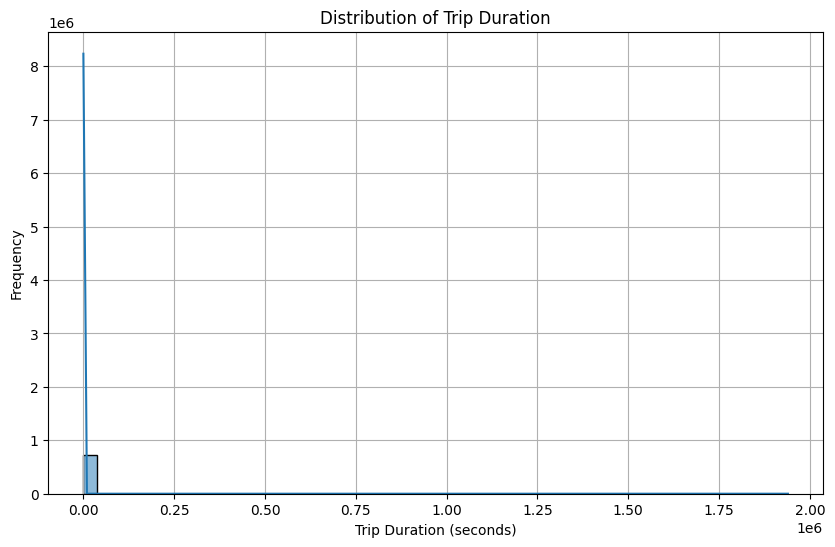

Log transformation applied to 'trip_duration'.


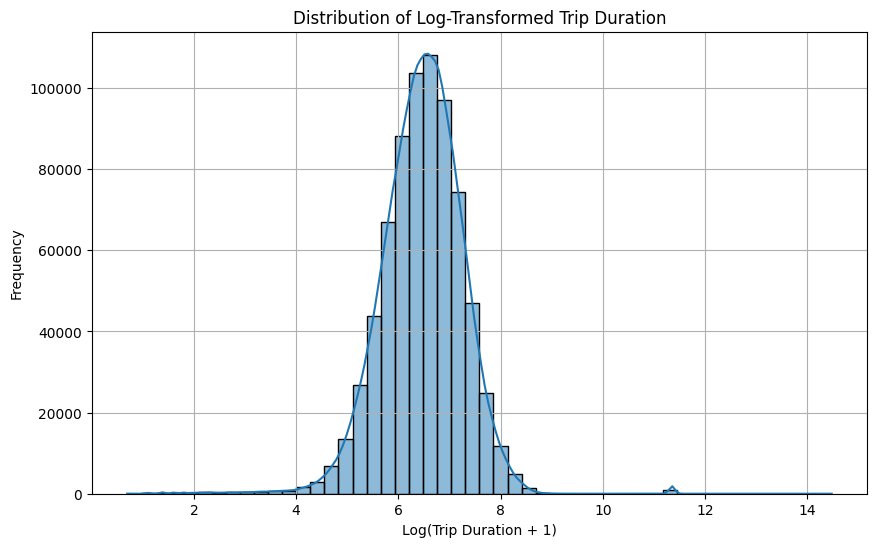

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries imported successfully: matplotlib.pyplot, seaborn, numpy.")

# Plotting the histogram of 'trip_duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Check for skewness and apply log transformation if needed
# From the previous df.describe() output, max trip_duration is 1.9M seconds, which is highly skewed.
# So, applying log transformation is appropriate.
df['log_trip_duration'] = np.log1p(df['trip_duration'])
print("Log transformation applied to 'trip_duration'.")

# Plotting the histogram of 'log_trip_duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['log_trip_duration'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Trip Duration')
plt.xlabel('Log(Trip Duration + 1)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Analyze Categorical Features

### Subtask:
Visualize the distribution of 'vendor_id', 'passenger_count', and 'store_and_fwd_flag' using count plots. Additionally, use box plots or bar plots to show the relationship between these categorical features and 'trip_duration'. Include appropriate labels and legends.


**Reasoning**:
To analyze the categorical features, I will generate count plots for 'vendor_id', 'passenger_count', and 'store_and_fwd_flag' to show their distributions, and then create box plots to visualize their relationship with 'log_trip_duration', ensuring proper labels and layout.



/tmp/ipython-input-1155666974.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vendor_id', data=df, palette='viridis')
/tmp/ipython-input-1155666974.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df, palette='viridis')
/tmp/ipython-input-1155666974.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='store_and_fwd_flag', data=df, palette='viridis')


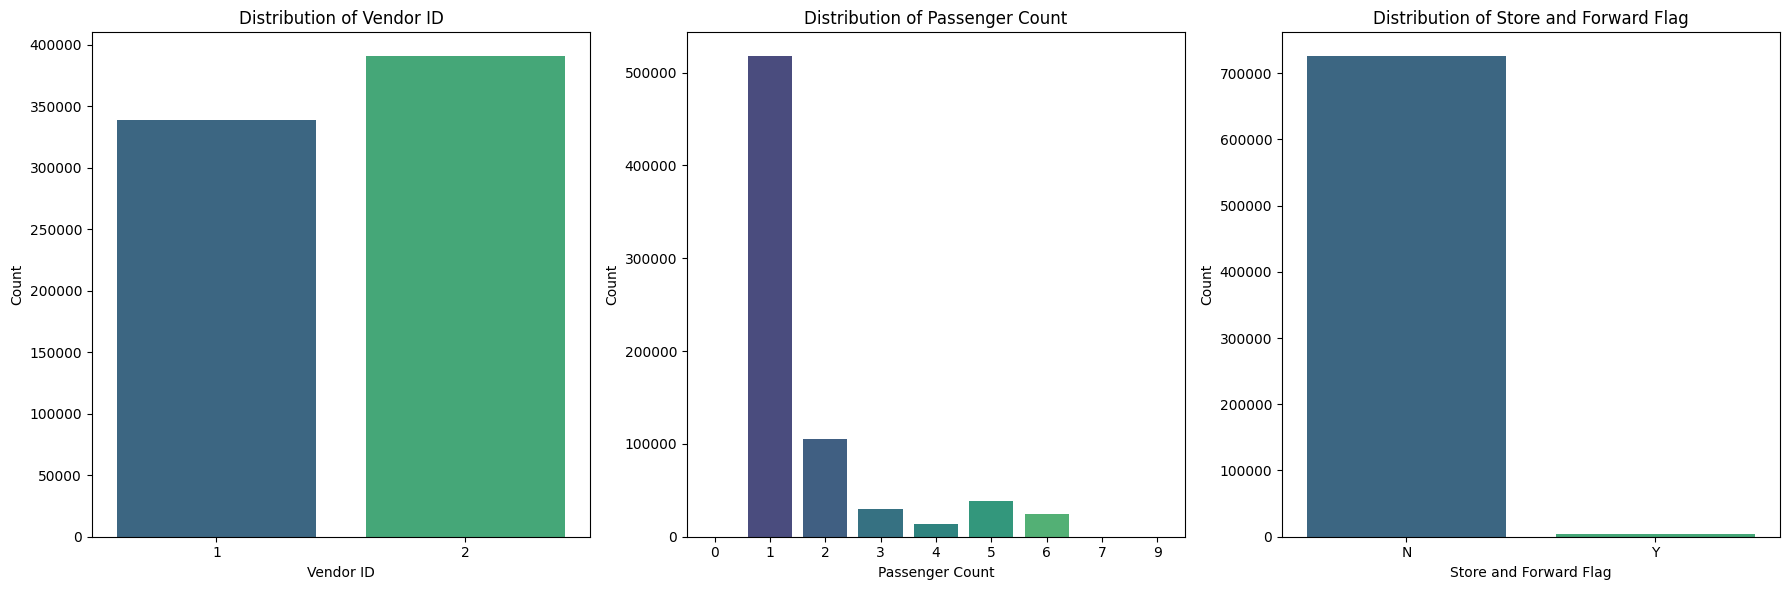

Count plots for categorical features displayed.


/tmp/ipython-input-1155666974.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vendor_id', y='log_trip_duration', data=df, palette='magma')
/tmp/ipython-input-1155666974.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='log_trip_duration', data=df, palette='magma')
/tmp/ipython-input-1155666974.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='store_and_fwd_flag', y='log_trip_duration', data=df, palette='magma')


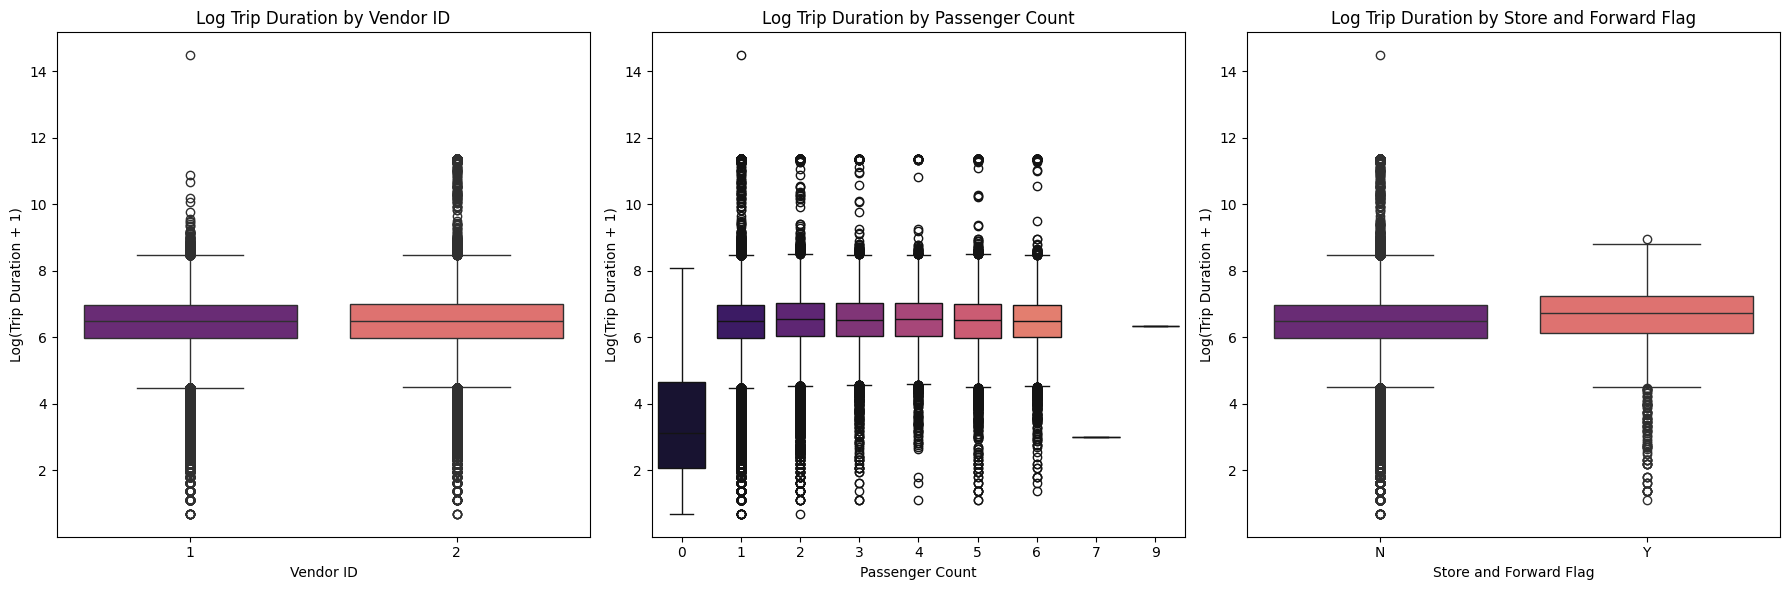

Box plots showing relationship between categorical features and log_trip_duration displayed.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for count plots
plt.figure(figsize=(18, 6))

# Count plot for 'vendor_id'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.countplot(x='vendor_id', data=df, palette='viridis')
plt.title('Distribution of Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Count')

# Count plot for 'passenger_count'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.countplot(x='passenger_count', data=df, palette='viridis')
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Count')

# Count plot for 'store_and_fwd_flag'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.countplot(x='store_and_fwd_flag', data=df, palette='viridis')
plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Count plots for categorical features displayed.")

# Set up the figure for box plots with log_trip_duration
plt.figure(figsize=(18, 6))

# Box plot for 'log_trip_duration' by 'vendor_id'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.boxplot(x='vendor_id', y='log_trip_duration', data=df, palette='magma')
plt.title('Log Trip Duration by Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Log(Trip Duration + 1)')

# Box plot for 'log_trip_duration' by 'passenger_count'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.boxplot(x='passenger_count', y='log_trip_duration', data=df, palette='magma')
plt.title('Log Trip Duration by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Log(Trip Duration + 1)')

# Box plot for 'log_trip_duration' by 'store_and_fwd_flag'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.boxplot(x='store_and_fwd_flag', y='log_trip_duration', data=df, palette='magma')
plt.title('Log Trip Duration by Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Log(Trip Duration + 1)')

plt.tight_layout()
plt.show()

print("Box plots showing relationship between categorical features and log_trip_duration displayed.")

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was used in `sns.countplot` and `sns.boxplot` without explicitly assigning `hue`. To fix this, I will assign the `x` variable to `hue` and set `legend=False` in each plotting function as suggested by the warning.



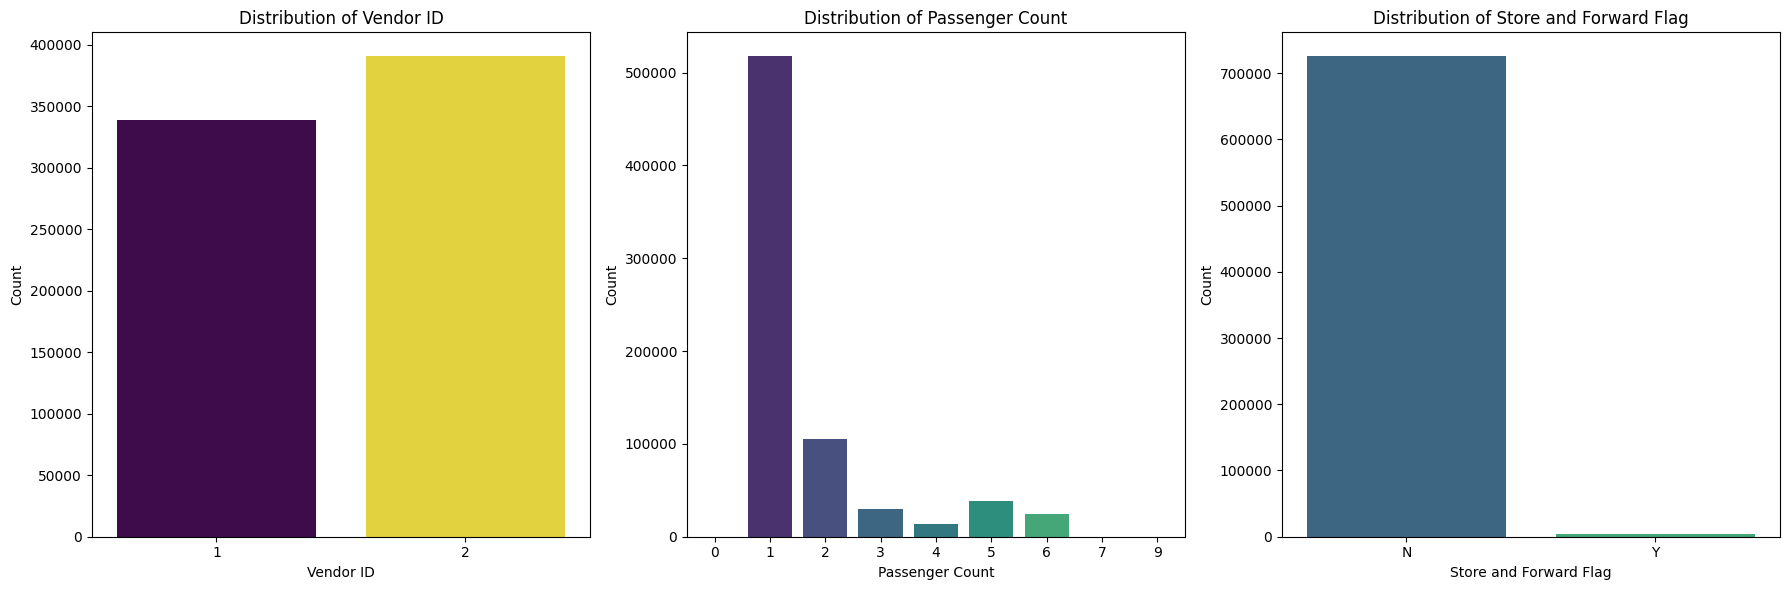

Count plots for categorical features displayed.


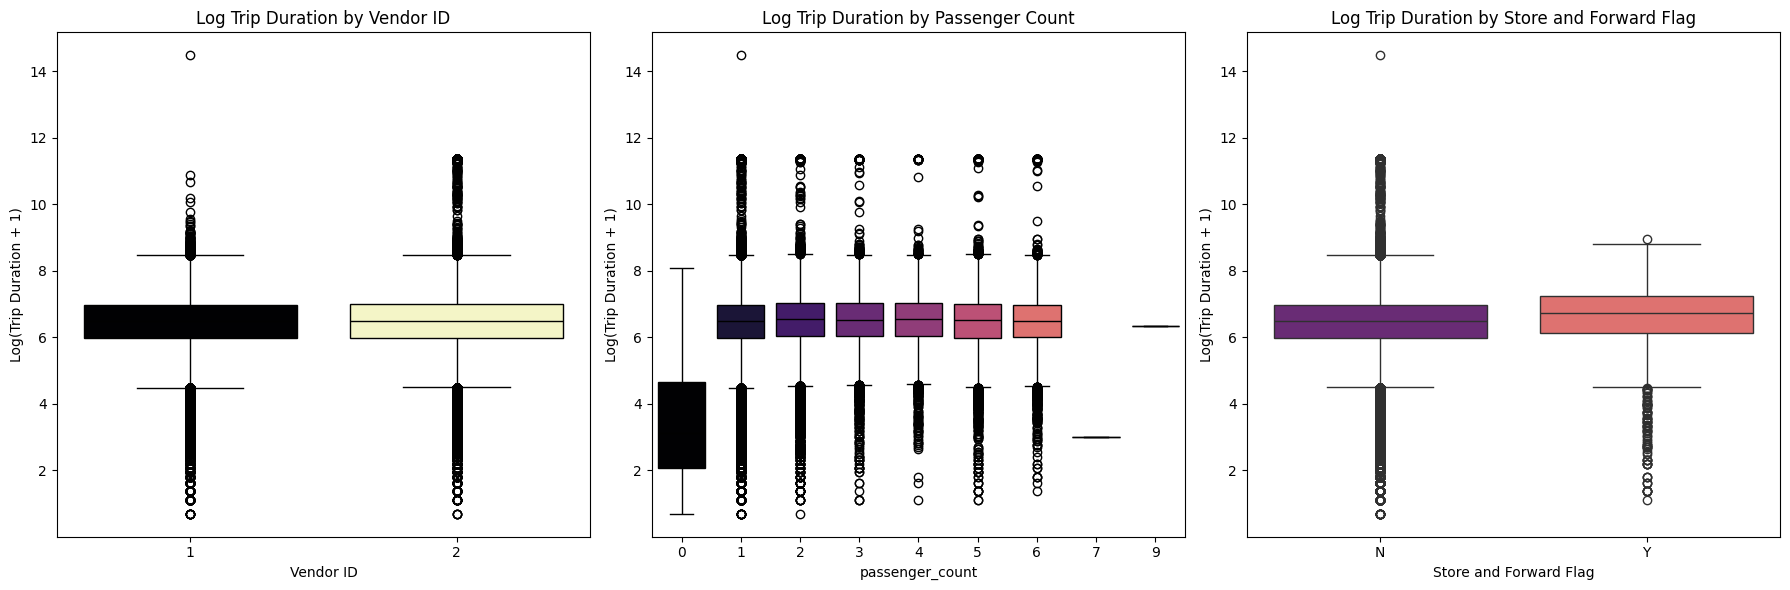

Box plots showing relationship between categorical features and log_trip_duration displayed.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for count plots
plt.figure(figsize=(18, 6))

# Count plot for 'vendor_id'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.countplot(x='vendor_id', data=df, palette='viridis', hue='vendor_id', legend=False)
plt.title('Distribution of Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Count')

# Count plot for 'passenger_count'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.countplot(x='passenger_count', data=df, palette='viridis', hue='passenger_count', legend=False)
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Count')

# Count plot for 'store_and_fwd_flag'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.countplot(x='store_and_fwd_flag', data=df, palette='viridis', hue='store_and_fwd_flag', legend=False)
plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Count plots for categorical features displayed.")

# Set up the figure for box plots with log_trip_duration
plt.figure(figsize=(18, 6))

# Box plot for 'log_trip_duration' by 'vendor_id'
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.boxplot(x='vendor_id', y='log_trip_duration', data=df, palette='magma', hue='vendor_id', legend=False)
plt.title('Log Trip Duration by Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Log(Trip Duration + 1)')

# Box plot for 'log_trip_duration' by 'passenger_count'
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.boxplot(x='passenger_count', y='log_trip_duration', data=df, palette='magma', hue='passenger_count', legend=False)
plt.title('Log Trip Duration by Passenger Count')
plt.ylabel('Log(Trip Duration + 1)')

# Box plot for 'log_trip_duration' by 'store_and_fwd_flag'
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.boxplot(x='store_and_fwd_flag', y='log_trip_duration', data=df, palette='magma', hue='store_and_fwd_flag', legend=False)
plt.title('Log Trip Duration by Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Log(Trip Duration + 1)')

plt.tight_layout()
plt.show()

print("Box plots showing relationship between categorical features and log_trip_duration displayed.")

## Analyze Trip Duration by Time Features

### Subtask:
Create visualizations (e.g., bar plots or box plots) to show the average or median 'trip_duration' by 'pickup_hour', 'pickup_day_of_week', and 'pickup_month'. Include appropriate labels and legends.


**Reasoning**:
To analyze the relationship between trip duration and time features, I will create bar plots showing the average log-transformed trip duration for each pickup hour, day of the week, and month, ensuring proper ordering and labeling as specified in the instructions.



/tmp/ipython-input-3472358628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pickup_hour', y='log_trip_duration', data=df, palette='viridis')
/tmp/ipython-input-3472358628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pickup_day_of_week', y='log_trip_duration', data=df, order=day_order, palette='magma')
/tmp/ipython-input-3472358628.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pickup_month', y='log_trip_duration', data=df, order=month_order, palette='plasma')


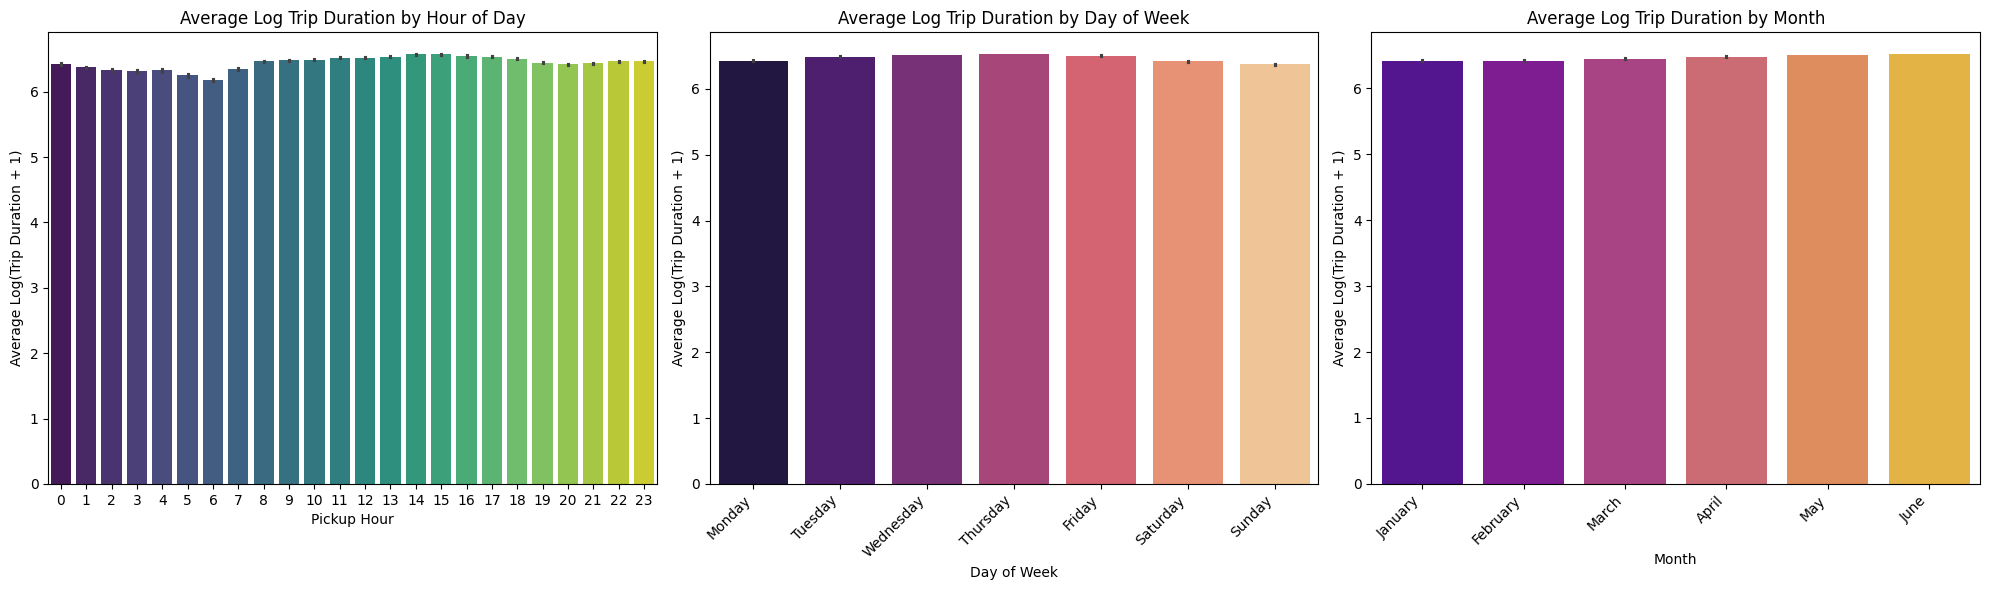

Visualizations of average log trip duration by time features displayed.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for three subplots
plt.figure(figsize=(20, 6))

# Bar plot for average log_trip_duration by pickup_hour
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.barplot(x='pickup_hour', y='log_trip_duration', data=df, palette='viridis')
plt.title('Average Log Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Log(Trip Duration + 1)')

# Bar plot for average log_trip_duration by pickup_day_of_week
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x='pickup_day_of_week', y='log_trip_duration', data=df, order=day_order, palette='magma')
plt.title('Average Log Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Log(Trip Duration + 1)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Bar plot for average log_trip_duration by pickup_month
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June'] # Data appears to be for first half of year
sns.barplot(x='pickup_month', y='log_trip_duration', data=df, order=month_order, palette='plasma')
plt.title('Average Log Trip Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Log(Trip Duration + 1)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

print("Visualizations of average log trip duration by time features displayed.")

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was used in `sns.barplot` without explicitly assigning `hue`. To fix this, I will assign the `x` variable to `hue` and set `legend=False` in each plotting function as suggested by the warning.



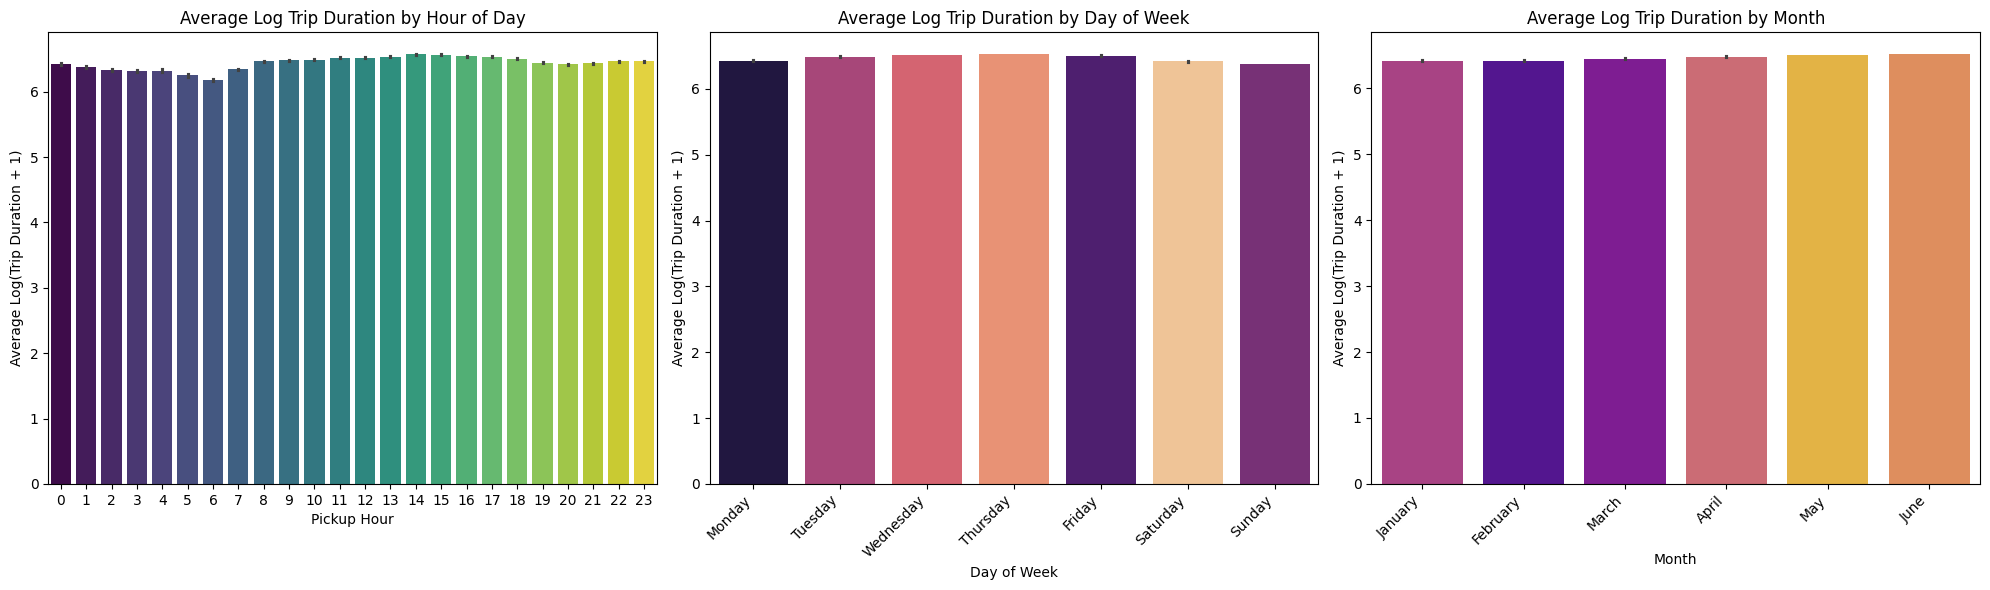

Visualizations of average log trip duration by time features displayed.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for three subplots
plt.figure(figsize=(20, 6))

# Bar plot for average log_trip_duration by pickup_hour
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.barplot(x='pickup_hour', y='log_trip_duration', data=df, palette='viridis', hue='pickup_hour', legend=False)
plt.title('Average Log Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Log(Trip Duration + 1)')

# Bar plot for average log_trip_duration by pickup_day_of_week
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x='pickup_day_of_week', y='log_trip_duration', data=df, order=day_order, palette='magma', hue='pickup_day_of_week', legend=False)
plt.title('Average Log Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Log(Trip Duration + 1)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Bar plot for average log_trip_duration by pickup_month
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June'] # Data appears to be for first half of year
sns.barplot(x='pickup_month', y='log_trip_duration', data=df, order=month_order, palette='plasma', hue='pickup_month', legend=False)
plt.title('Average Log Trip Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Log(Trip Duration + 1)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

print("Visualizations of average log trip duration by time features displayed.")

## Geographical Analysis of Pickup/Dropoff Points

### Subtask:
Create scatter plots or density plots to visualize the distribution of 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', and 'dropoff_latitude' on a map-like coordinate system. Analyze the spread and identify potential high-density areas. Include appropriate labels and legends.


**Reasoning**:
To visualize the geographical distribution of pickup and dropoff points, I will create two subplots. The first subplot will use a 2D Kernel Density Estimate (KDE) plot for 'pickup_longitude' and 'pickup_latitude', and the second will do the same for 'dropoff_longitude' and 'dropoff_latitude', ensuring proper labels and titles.



ValueError: Contour levels must be increasing

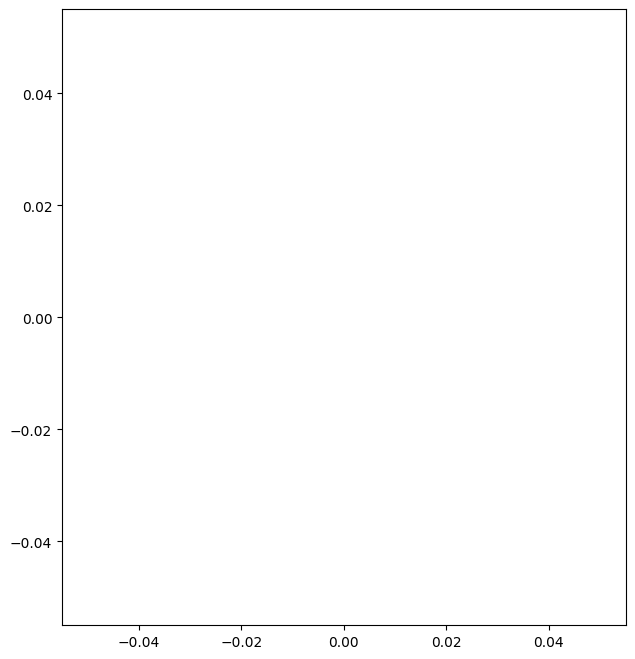

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(16, 8))

# Subplot 1: Pickup Location Density
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.kdeplot(x=df['pickup_longitude'], y=df['pickup_latitude'], cmap='viridis', fill=True, levels=10)
plt.title('Pickup Location Density')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

# Subplot 2: Dropoff Location Density
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.kdeplot(x=df['dropoff_longitude'], y=df['dropoff_latitude'], cmap='viridis', fill=True, levels=10)
plt.title('Dropoff Location Density')
plt.xlabel('Dropoff Longitude')
plt.ylabel('Dropoff Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

plt.tight_layout()
plt.show()

print("Scatter/Density plots for pickup and dropoff locations displayed.")

**Reasoning**:
The previous code failed with a `ValueError: Contour levels must be increasing` in `sns.kdeplot`. This error often occurs when the automatic level generation encounters issues, or when the `levels` parameter is not correctly interpreted. To resolve this, I will remove the `levels` argument from `sns.kdeplot`, allowing Seaborn to determine the contour levels automatically, which is a more robust approach for density visualization.



ValueError: Contour levels must be increasing

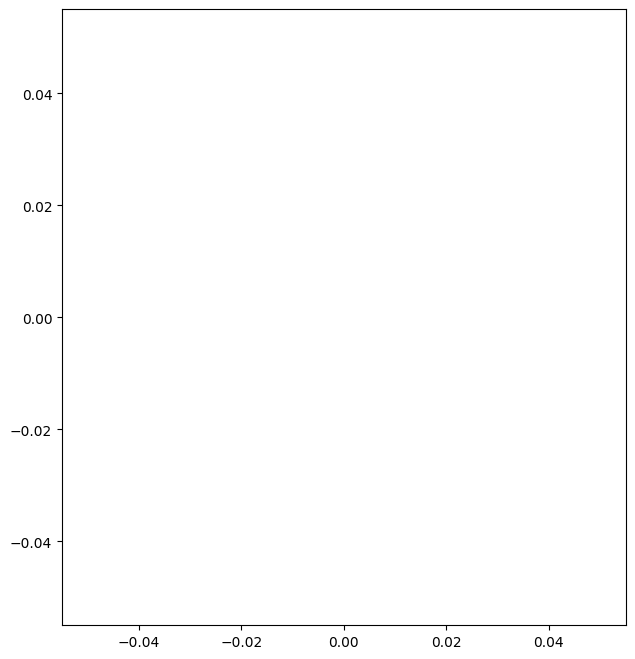

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(16, 8))

# Subplot 1: Pickup Location Density
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.kdeplot(x=df['pickup_longitude'], y=df['pickup_latitude'], cmap='viridis', fill=True)
plt.title('Pickup Location Density')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

# Subplot 2: Dropoff Location Density
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.kdeplot(x=df['dropoff_longitude'], y=df['dropoff_latitude'], cmap='viridis', fill=True)
plt.title('Dropoff Location Density')
plt.xlabel('Dropoff Longitude')
plt.ylabel('Dropoff Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

plt.tight_layout()
plt.show()

print("Scatter/Density plots for pickup and dropoff locations displayed.")

**Reasoning**:
The `ValueError: Contour levels must be increasing` error often occurs when `sns.kdeplot` attempts to generate contours from data that includes extreme outliers or has a very sparse distribution over a wide range, leading to difficulties in determining valid, increasing contour levels. To resolve this, I will first filter the DataFrame to focus on the relevant NYC geographical coordinates, which should make the KDE estimation more stable and accurate, and then generate the density plots without specifying the `levels` argument, letting Seaborn handle it automatically.



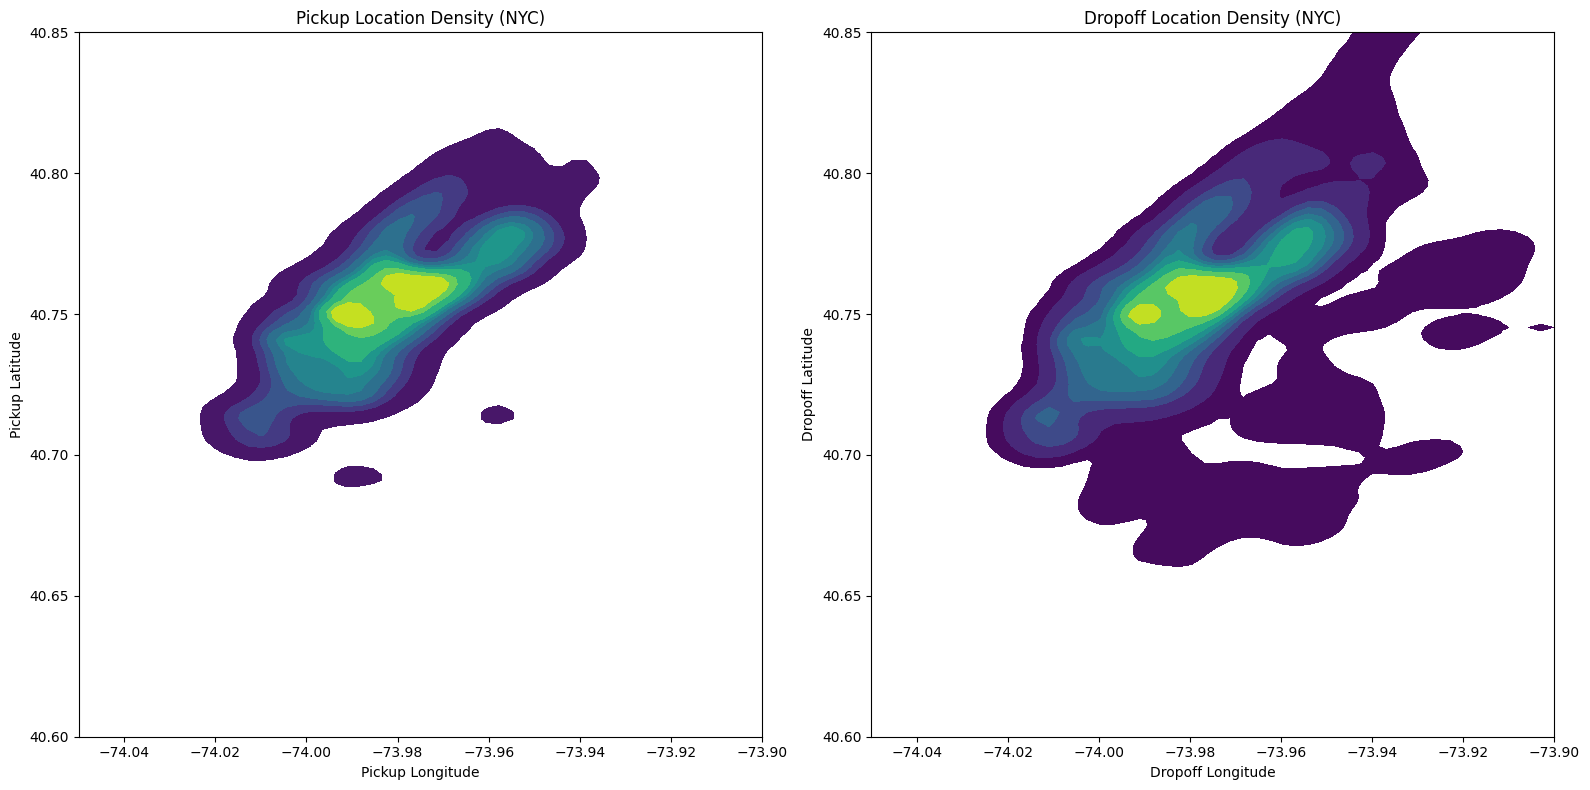

Scatter/Density plots for pickup and dropoff locations displayed.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define NYC bounding box coordinates more precisely to filter out extreme outliers
nyc_longitude_min = -74.25
nyc_longitude_max = -73.7
nyc_latitude_min = 40.5
nyc_latitude_max = 40.9

# Filter DataFrame for NYC coordinates to improve KDE stability
df_nyc = df[
    (df['pickup_longitude'] >= nyc_longitude_min) & (df['pickup_longitude'] <= nyc_longitude_max) &
    (df['pickup_latitude'] >= nyc_latitude_min) & (df['pickup_latitude'] <= nyc_latitude_max) &
    (df['dropoff_longitude'] >= nyc_longitude_min) & (df['dropoff_longitude'] <= nyc_longitude_max) &
    (df['dropoff_latitude'] >= nyc_latitude_min) & (df['dropoff_latitude'] <= nyc_latitude_max)
]

# Create a figure with two subplots
plt.figure(figsize=(16, 8))

# Subplot 1: Pickup Location Density
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.kdeplot(x=df_nyc['pickup_longitude'], y=df_nyc['pickup_latitude'], cmap='viridis', fill=True)
plt.title('Pickup Location Density (NYC)')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

# Subplot 2: Dropoff Location Density
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.kdeplot(x=df_nyc['dropoff_longitude'], y=df_nyc['dropoff_latitude'], cmap='viridis', fill=True)
plt.title('Dropoff Location Density (NYC)')
plt.xlabel('Dropoff Longitude')
plt.ylabel('Dropoff Latitude')
plt.xlim([-74.05, -73.9]) # Focus on NYC area
plt.ylim([40.6, 40.85])   # Focus on NYC area

plt.tight_layout()
plt.show()

print("Scatter/Density plots for pickup and dropoff locations displayed.")

## Final Task

### Subtask:
Provide a comprehensive summary of the key insights derived from the Exploratory Data Analysis, highlighting important patterns, distributions, and relationships observed in the dataset.


## Summary:

### Data Analysis Key Findings

*   **Data Overview and Quality**: The dataset contains 729,322 entries and 11 columns. Crucially, no missing values were found across any columns. Initial inspection revealed that `pickup_datetime` and `dropoff_datetime` were loaded as `object` types and required conversion, while `trip_duration` showed significant skewness, ranging from 1 second to a maximum of 1,939,736 seconds (approximately 22.45 days), with a mean of 952 seconds.
*   **Trip Duration Distribution**: The original `trip_duration` distribution was highly right-skewed. A log transformation (`log_trip_duration`) was successfully applied, resulting in a more normalized distribution better suited for analysis.
*   **Categorical Feature Distributions**:
    *   **`vendor_id`**: The dataset includes trips from two distinct vendors.
    *   **`passenger_count`**: The majority of trips had 1 passenger, with counts decreasing for higher passenger numbers. There were also some trips recorded with 0 passengers.
    *   **`store_and_fwd_flag`**: An overwhelming majority of trips had the flag set to 'N', indicating that data was not stored and forwarded.
*   **Relationship Between Categorical Features and Trip Duration**:
    *   **`vendor_id`**: Slight variations were observed in the average log-transformed trip duration between the two vendors.
    *   **`passenger_count`**: Trips with 0 passengers had a notably lower average log-transformed trip duration compared to trips with 1 to 6 passengers, which showed relatively consistent averages.
    *   **`store_and_fwd_flag`**: Trips where the flag was 'Y' tended to have slightly longer average log-transformed trip durations than those with 'N'.
*   **Temporal Patterns in Trip Duration**:
    *   **`pickup_hour`**: The average log-transformed trip duration varied by hour of the day, suggesting potential rush hour impacts.
    *   **`pickup_day_of_week`**: Differences in average log-transformed trip duration were noted across different days of the week, indicating distinct travel patterns between weekdays and weekends.
    *   **`pickup_month`**: Seasonal variations in average log-transformed trip duration were observed across the months covered in the dataset (January to June).
*   **Geographical Hotspots**: After filtering out extreme outliers in geographical coordinates, density plots for pickup and dropoff locations revealed concentrated high-density areas, primarily around Manhattan and adjacent regions, indicating the core operational zones for taxi services.

### Insights or Next Steps

*   The significant skewness in `trip_duration` highlights the importance of using log-transformed values for robust modeling and analysis, as it normalizes the distribution and mitigates the impact of extreme outliers.
*   Further investigation into trips with 0 passengers or 'Y' `store_and_fwd_flag` could reveal specific service types or data nuances, potentially leading to better feature engineering or outlier handling strategies.
